In [1]:
print("hi")

hi


In [2]:
words = open(r"C:\Users\PRECISION\Downloads\names.txt", "r").read().splitlines()


In [3]:
print(words[:5])

['emma', 'olivia', 'ava', 'isabella', 'sophia']


In [3]:
print(len(words))

32033


In [4]:
min(len(w)for w in words)

2

In [5]:
max(len(w)for w in words)

15

In [21]:
b={}
for w in words:
    chs =['<S>'] + list(w) + ['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram=(ch1,ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [ ]:
sorted(b.items(), key=lambda kv: -kv[1])
#sorted does sort by the first element of the tuple, which is the bigram, so we need to use a lambda function to sort by the second element, which is the count. We also use -kv[1] to sort in descending order.

In [3]:
import torch

In [4]:
a = torch.zeros((3,5),dtype = torch.int32)

In [5]:
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [46]:
 a[1,3] += 1

In [20]:
N=torch.zeros((27,27),dtype = torch.int32)
#N keeps the transition counts between characters. We have 27 characters: 26 letters + <S> + <E>

In [56]:
char=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(char)}
stoi['.'] = 0
itos={i:s for s,i in stoi.items()}

In [57]:
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [58]:

for w in words:
    chs =['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
      ix1=stoi[ch1]
      ix2=stoi[ch2]
      N[ix1,ix2] += 1

In [59]:
itos={i:s for s,i in stoi.items()}

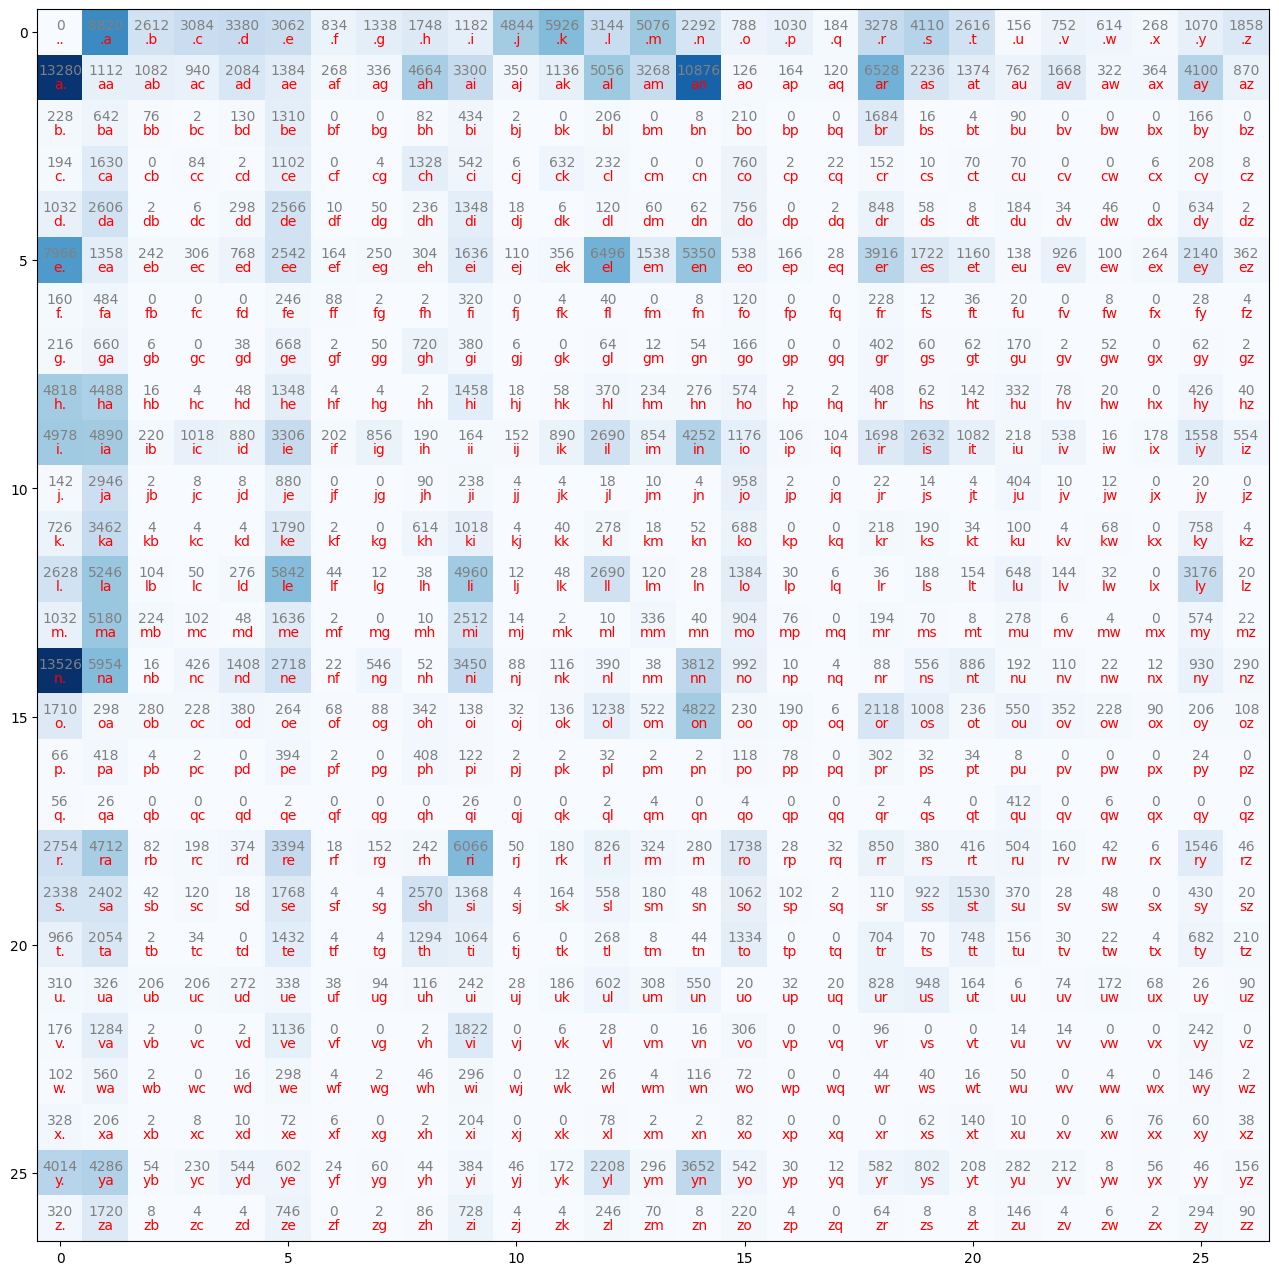

In [60]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i]+itos[j]
        plt.text(j,i,N[i,j].item(), ha='center', va='bottom', color='gray')
        plt.text(j,i,chstr, ha='center', va='top', color='red')

In [45]:
N[0,:].shape
#N[0] both are the same, but N[0,:] is more explicit that we want the first row. N[0] can be ambiguous because it can also mean the first element of the array, which is a row vector. N[0,:] makes it clear that we want the first row and all columns.

torch.Size([27])

In [61]:
p=N[0].float()
p=p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [68]:
g=torch.Generator().manual_seed(2147483647)
idx=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
itos[idx]

'.'

In [65]:
g=torch.Generator().manual_seed(2147483647)
p=torch.rand(3, generator=g)
#p
p=p/p.sum()

In [66]:
torch.multinomial(p,num_samples=10,replacement=True,generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0])

In [67]:
p

tensor([0.6064, 0.3033, 0.0903])

In [51]:
p.sum()

tensor(1.)

In [30]:
#stoi

In [77]:
g=torch.Generator().manual_seed(2147483647)
for i in range(20):
 out =[]
 ix=0
 while True:
    p=N[ix].float()
    p=p/p.sum()
    
    idx=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
    
    if idx==0:
        break
    out.append(itos[idx])
    ix=idx
 print(''.join(out))

junide
janasah
p
cony
a
nn
kohin
tolian
juee
ksahnaauranilevias
dedainrwieta
ssonielylarte
faveumerifontume
phynslenaruani
core
yaenon
ka
jabdinerimikimaynin
anaasn
ssorionsush
